In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("airlines_flights_data.csv")
df.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [3]:
df.drop("index",axis = 1, inplace = True)

In [4]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 300153
Number of Columns: 11


<Axes: xlabel='price', ylabel='Count'>

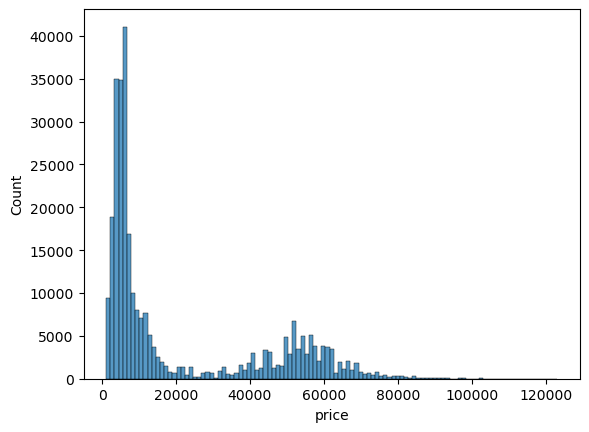

In [5]:
sns.histplot(df["price"])

In [6]:
df.drop("flight",axis = 1, inplace = True)

In [7]:
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [8]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("=" * 60)
    print(f"Column: {col}")
    print(df.groupby(col)["price"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False))

Column: airline
                   mean   median   count
airline                                 
Vistara    30396.536302  15543.0  127859
Air_India  23507.019112  11520.0   80892
SpiceJet    6179.278881   5654.0    9011
GO_FIRST    5652.007595   5336.0   23173
Indigo      5324.216303   4453.0   43120
AirAsia     4091.072742   3276.0   16098
Column: source_city
                     mean  median  count
source_city                             
Chennai      21995.339871  7846.0  38700
Kolkata      21746.235679  7958.0  46347
Mumbai       21483.818839  7413.0  60896
Bangalore    21469.460575  7488.0  52061
Hyderabad    20155.623879  6855.0  40806
Delhi        18951.326639  6840.0  61343
Column: departure_time
                        mean  median  count
departure_time                             
Night           23062.146808  7813.0  48015
Morning         21630.760254  8112.0  71146
Evening         21232.361894  7425.0  65102
Early_Morning   20370.676718  7212.0  66790
Afternoon       18179

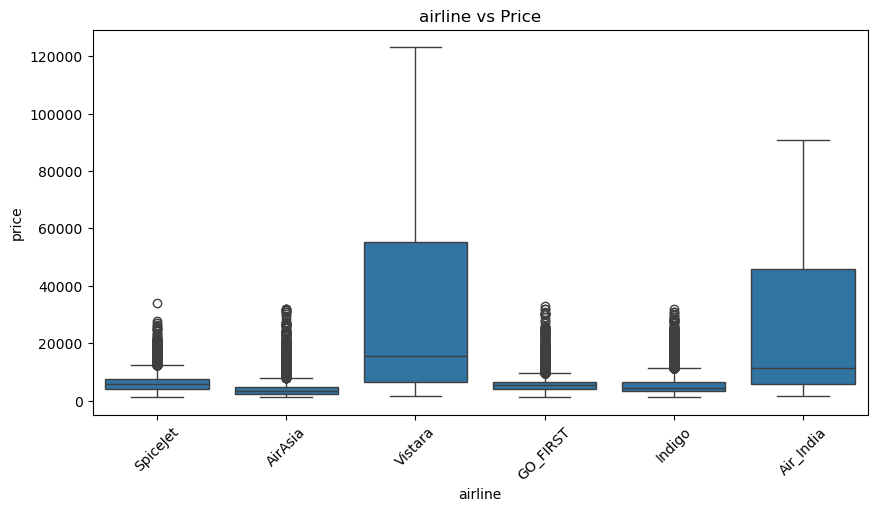

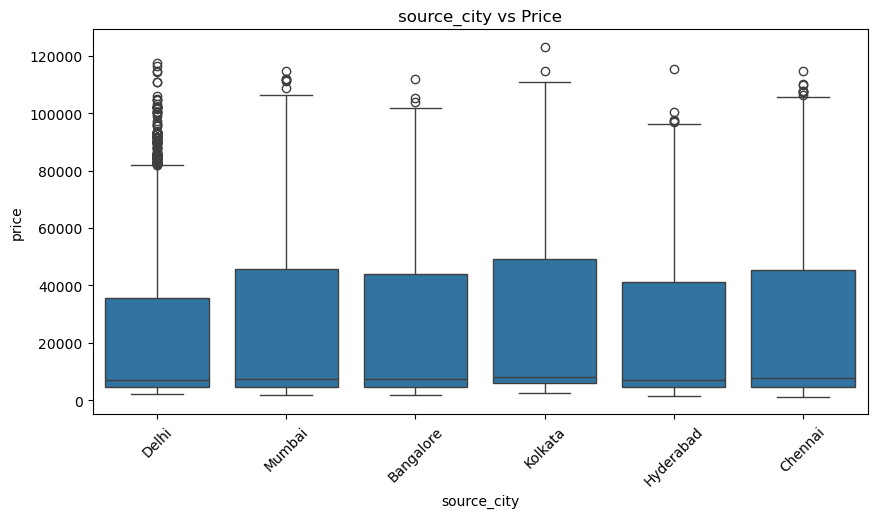

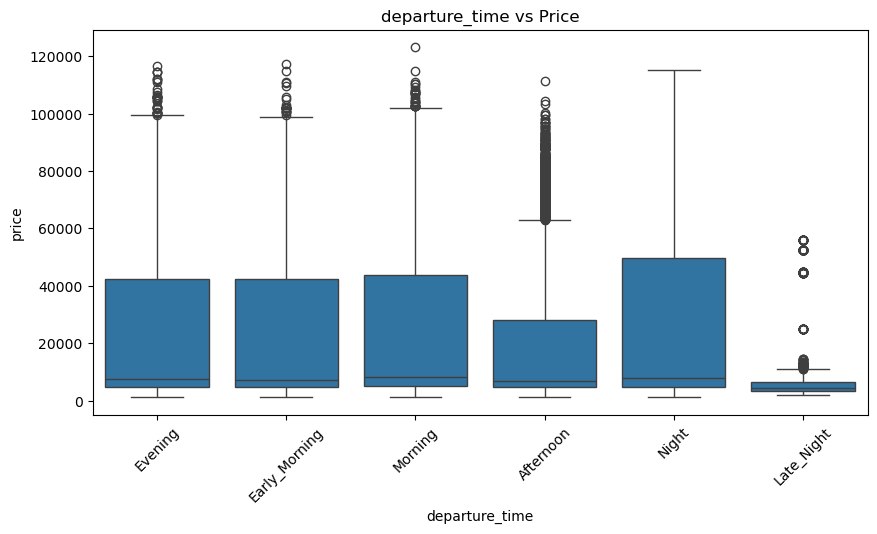

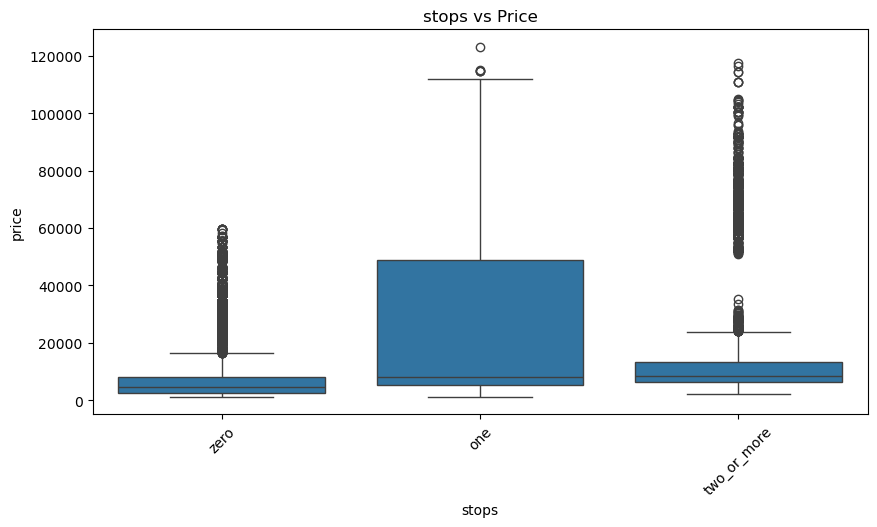

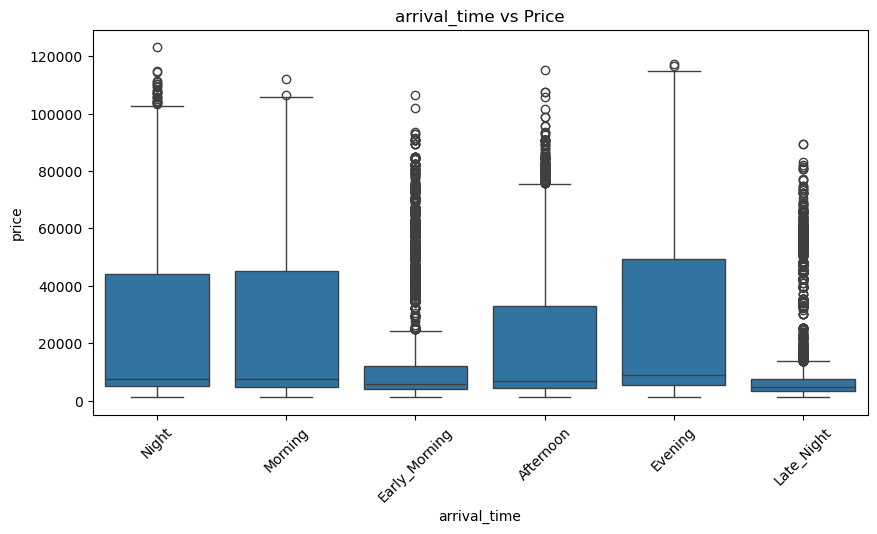

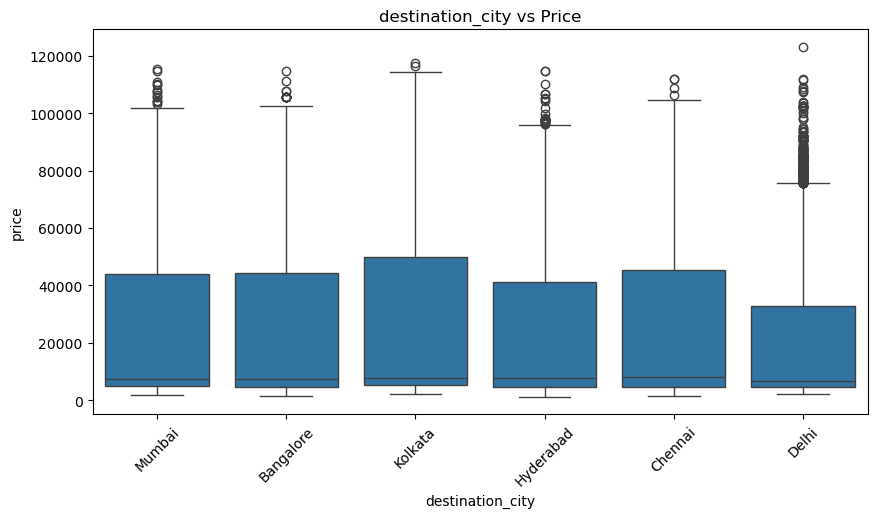

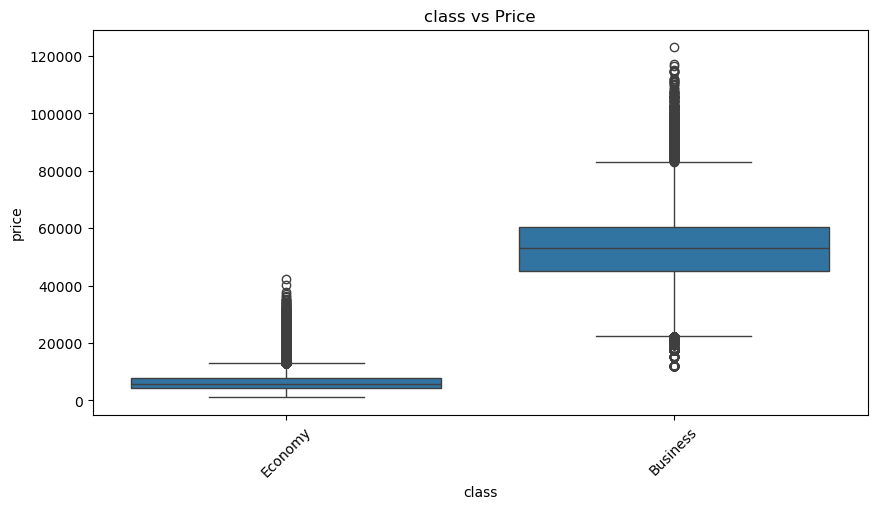

In [9]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=col, y="price")
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Price")
    plt.show()

In [10]:
from scipy.stats import f_oneway

categorical_cols = df.select_dtypes(include="object").columns

results = []

for col in categorical_cols:
    
    groups = [
        group["price"].values
        for _, group in df.groupby(col)
    ]
    
    f_stat, p_value = f_oneway(*groups)
    
    results.append({
        "Feature": col,
        "F-Statistic": f_stat,
        "P-Value": p_value
    })

anova_results = pd.DataFrame(results)

anova_results.sort_values("P-Value")

,Feature,F-Statistic,P-Value
0,airline,1.719440e+04,0.000000e+00
2,departure_time,3.192425e+02,0.000000e+00
3,stops,6.477130e+03,0.000000e+00
4,arrival_time,1.013504e+03,0.000000e+00
6,class,2.192425e+06,0.000000e+00
5,destination_city,1.930575e+02,4.245267e-206
1,source_city,1.450622e+02,2.550099e-154


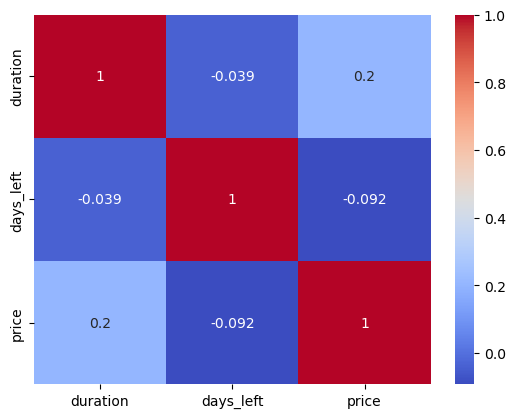

In [11]:
sns.heatmap(
    df[["duration", "days_left", "price"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [12]:
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [13]:
cat_cols = ["airline","source_city","departure_time","stops","arrival_time","destination_city","class"]

df_encoded = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
).astype(int)

In [14]:
df_encoded

,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,source_city_Delhi,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,2,1,5953,0,0,0,1,0,0,1,...,0,0,0,1,0,0,0,0,1,1
1,2,1,5953,0,0,0,1,0,0,1,...,0,0,1,0,0,0,0,0,1,1
2,2,1,5956,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,1
3,2,1,5955,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,1,1
4,2,1,5955,0,0,0,0,1,0,1,...,0,0,1,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,10,49,69265,0,0,0,0,1,1,0,...,1,0,0,0,0,0,1,0,0,0
300149,10,49,77105,0,0,0,0,1,1,0,...,0,0,0,1,0,0,1,0,0,0
300150,13,49,79099,0,0,0,0,1,1,0,...,0,0,0,1,0,0,1,0,0,0
300151,10,49,81585,0,0,0,0,1,1,0,...,1,0,0,0,0,0,1,0,0,0


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x = df_encoded.drop("price",axis = 1)
y = df["price"]

x_train, x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


num_cols = ["duration","days_left"]


scaler = StandardScaler()
# Fit ONLY on training data
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])

# Transform test data using the same scaler
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [17]:
model = LinearRegression()

model.fit(x_train,y_train)
y_pred = model.predict(x_test)


In [18]:
y_pred[0:6]

array([ 3422.32709263, 55132.09268333, 10409.82632715, 54919.38672433,
        6610.12764354,  9850.5563513 ])

In [19]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.9113125698039832
MAE: 4552.943761275637
RMSE: 6761.419832729176


In [20]:
import joblib

# Save trained model
joblib.dump(model, "linear_regression_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save feature columns
joblib.dump(x_train.columns.tolist(), "feature_columns.pkl")

print("All files saved successfully!")

All files saved successfully!
